# Mixture of Experts with Megatron‑Bridge

## When, How, and a Peek Under the Hood

A practical playbook in three layers: **concepts** → **single-GPU training** → **optional multi-GPU / production** (appendix).

> **Environment:** This notebook was developed on an NVIDIA DGX Spark using the [`nvcr.io/nvidia/nemo:26.04.00`](https://catalog.ngc.nvidia.com/orgs/nvidia/containers/nemo) container.

### How to read this notebook

| Path | What to read | Rough time |
|------|----------------|------------|
| **Path 1 — Essentials** | §1 → §2 → §3 → §6 checklist | ~30 min |
| **Path 2 — Full** | Path 1 + **Appendix** (dispatch, parallelism, production, tuning) | 1–2 hrs |

**Legend:** 🧠 Concepts · 🏋️ Training · 🖥️ Multi-GPU / Megatron (appendix)

Only a few cells execute code (environment check + MoE micro-train). Megatron-Bridge snippets are **reference-only** unless you install that stack.

![One MoE layer: input → router (top-2 of three experts) → gated expert outputs → sum → output](moe_assets/moe_layer_schematic.png)


## Glossary (quick reference)

| Term | Meaning |
|------|---------|
| **Expert** | One of `N` feed-forward (FFN) networks in an MoE layer |
| **Router** | Small network that scores which expert(s) each **token** should use |
| **top-k** | How many experts run per token (e.g. 2 → top-2 routing) |
| **Total vs active params** | All experts count toward **total** size; only **top-k** experts contribute **compute** per token |
| **EP** (expert parallel) | Experts split across GPUs; tokens may move between GPUs |
| **TP** / **PP** | Tensor / pipeline parallel — split weights or layers across GPUs |
| **Dispatch** | **Moving** token activations to the GPU that owns an expert (only when EP > 1) |
| **GroupedGEMM** | Fused batched matmuls — one kernel for all experts' tokens |
| **aux_loss** | Training-only penalty to spread load across experts |
| **Dropless / capacity** | Training policies when an expert queue is full (see FAQ) |


## FAQ — common confusions

**Total parameters vs “active” compute**

MoE models are often **large in total parameters** (all experts stored) but **sparse in compute**: each token only runs **top-k** of `N` experts. “Active compute per token” ≈ `k/N` of expert FLOPs — not “loading experts from disk one at a time.”

**Do weights get unloaded per token?**

Usually **no**. On one GPU (EP=1), **all experts typically stay in GPU memory**; the router picks which to **execute**. Unloading/reloading per token would be far too slow. Expert parallelism **shards** experts across GPUs and **sends activations**, not lazy weight loading.

**Can two words in the same sentence use different experts?**

**Yes.** Routing is **per token** (per position) from that token’s hidden state. “The **cat** sat on the mat” might route “cat” to experts {1,3} and “sat” to {0,2}.

**Is `aux_loss` used at inference?**

**No — training only.** It encourages balanced expert use while learning. At inference you use the trained router; there is no aux term in the loss.

**Capacity-based drops — are requests “not served”?**

This is a **training-time** policy when an expert’s batch is full: extra tokens may be **dropped** (or handled by a fallback) to improve balance. **Dropless** never drops but can overload hot experts. This is not an HTTP-style “request failed.”

**Routing vs dispatching vs allgather**

| Step | What | When |
|------|------|------|
| **Routing** | Decide top-k experts for each token | Always |
| **Dispatch** | Move tokens to the GPU that **owns** those experts | EP > 1 only |
| **allgather / alltoall** | Multi-GPU **communication patterns** for dispatch | Appendix |

On **one GPU**, dispatch is basically **reordering tokens in memory** (permute) — no network collectives.


## 1. When Should You Use MoE?

### When MoE is a Good Fit

Mixture of Experts architectures shine in specific scenarios where you need dense-model quality at a fraction of the compute cost:

- **Large-scale models with budget constraints**: When you need large-model quality but can't afford the full dense compute budget. MoE allows you to scale model capacity (total parameters) while keeping active compute per token similar to smaller dense models.
  
- **Multi-task or multi-domain workloads**: When your training data spans diverse domains (code, medical, legal, etc.) or tasks, different experts can specialize in different areas, improving overall quality without forcing a single dense model to learn everything.

- **GPU cluster deployments**: MoE parallelism (Expert Parallel, EP) maps naturally to multi-GPU setups. With multiple GPUs, you can distribute experts across devices and leverage Expert Parallelism alongside Tensor and Pipeline Parallelism.

- **Inference optimization scenarios**: When you need high throughput with constrained per-token latency, MoE's sparse activation (only top-k experts are active) can provide better throughput/cost than equivalently-sized dense models.

### When to Avoid MoE

MoE adds complexity and isn't always the right choice:

- **Simple setups or small budgets**: If you're running on 1-2 GPUs or have limited engineering resources, the operational overhead (debugging EP, load balancing, token routing) may outweigh benefits. Start with dense models.

- **Small models or datasets**: For models under 1B parameters or limited training data, dense models often work as well or better with far less complexity.

- **Infrastructure that can't handle complex parallelism**: Multi-GPU MoE needs expert/tensor/pipeline parallel and dispatch tuning (see notebook **Appendix**). If your cluster has limited interconnect bandwidth or little distributed-training experience, dense models are safer.

- **Strict load balancing requirements**: MoE routers can create imbalanced expert usage, leading to stragglers. If your application requires perfectly uniform compute, you'll spend significant effort on load balancing (auxiliary losses, Sinkhorn routing, etc.).


## 2. How MoE works (concepts) 🧠

*Layer A — mental model. Megatron flag names appear so you can map ideas to config later.*

### One MoE layer in four steps

1. **Router** scores each token against all experts.
2. **Top-k** experts are selected (e.g. k=2).
3. Those experts run the FFN; outputs are **weighted** and summed.
4. (Training) **Load balancing** encourages all experts to get work.

![MoE routing: router selects top-k experts](moe_assets/MoE_routing.png)

### Experts and routing

Instead of one large FFN, an MoE layer has `N` expert FFNs. A **router** (typically a linear layer + softmax) assigns each **token** to **top-k** experts. Only those experts run for that token.

- Megatron flags: `--num-experts`, `--moe-router-topk`

### Total size vs compute per token

| | Meaning |
|---|---------|
| **Total parameters** | All `N` experts + rest of model (weights usually **resident** on GPU) |
| **Active per token** | Only **k** experts run → ~`k/N` of expert FLOPs vs a dense FFN |

### Load balancing (training only) 🏋️

Without balancing, a few experts get most tokens (stragglers on multi-GPU). Megatron options:

- **aux_loss** — extra loss term; `moe_aux_loss_coeff` (typical `1e-2`). **Training only.**
- **sinkhorn** — stronger balance via normalized routing (more expensive).
- **aux_loss_free** — experimental balance without explicit aux loss.

- Flags: `--moe-router-load-balancing-type`, `--moe-aux-loss-coeff`

### Performance knobs (training) 🏋️

These matter for real training; the §3 micro-run does not use GroupedGEMM kernels.

- **GroupedGEMM** (`--moe-grouped-gemm`): fused expert GEMMs — critical for utilization.
- **Permute fusion** (`--moe-permute-fusion`): fuse token reordering with GEMM.

### Multi-GPU topics (skip for now) 🖥️

**Dispatch**, **dropless vs capacity**, **EP/TP/PP**, and **allgather/alltoall** matter when experts live on different GPUs. See the **Appendix** at the end of this notebook — not needed for Path 1.


### MoE token routing (top-k) — detail

Each token uses its own hidden vector at that position. **Different tokens in the same sentence can use different experts** — that is expected.

**Inference:** same routing, but **no** `aux_loss` in the loss.


## 3. Single-GPU MoE training quickstart 🏋️

*Layer B — minimal **training** config and a hands-on loop on one device.*

**Goal:** See the same knobs as Megatron-Bridge (`num_experts`, `top_k`, `aux_loss`) in a tiny PyTorch training loop — not full cluster pretrain.

**You will:** check the environment → review a reference config → run micro-train → use the **§6 checklist** below.

> **Note:** `moe_token_dispatcher_type: allgather` in the reference dict is for **multi-GPU** (EP > 1). With `expert_model_parallel_size: 1` it is inert on one GPU.

### Setup and environment check


In [ ]:
# Check for required packages
import sys

try:
    import torch
    print(f"✓ PyTorch {torch.__version__}")
    print(f"✓ CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
        print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
except ImportError:
    print("✗ PyTorch not found. Install with: pip install torch")

print("\nTip: Only a few cells run code (this check and the MoE micro-train).")
print("Path 1: run this check + the micro-train cell. Appendix snippets are reference-only.")


### MoE training configuration (reference)

Reference dict for a **minimal MoE training run** on one GPU (`expert_model_parallel_size: 1`). The hands-on cell uses these defaults if you do not define `moe_config` yourself.


Reference: MoE settings for single-GPU training. The micro-train cell uses the same numbers via its built-in fallback if you skip this cell.

**Path 1:** focus on *Model Settings* and *Training Settings*. *Performance Optimizations* / *Parallelism* matter for real Megatron runs (appendix).

```python
# Display key MoE settings for single-GPU training
moe_config = {
    "Model Settings": {
        "num_experts": 4,
        "moe_router_topk": 2,
        "moe_router_load_balancing_type": "aux_loss",
        "moe_aux_loss_coeff": 1e-2,
    },
    "Performance Optimizations (Megatron training)": {
        "moe_grouped_gemm": True,
        "moe_permute_fusion": True,
        "moe_token_dispatcher_type": "allgather",
    },
    "Parallelism (EP=1 on one GPU)": {
        "tensor_model_parallel_size": 1,
        "pipeline_model_parallel_size": 1,
        "expert_model_parallel_size": 1,
    },
    "Training Settings": {
        "train_iters": 10,
        "global_batch_size": 8,
        "micro_batch_size": 1,
    }
}

for category, settings in moe_config.items():
    print(f"\n{category}:")
    for key, value in settings.items():
        print(f"  {key}: {value}")
```


### Understanding the configuration

Reference: what each knob means. Tags: 🏋️ training · 🖥️ multi-GPU only · ⏭️ inference.

```python
# Configuration explanations
config_explanations = {
    "num_experts": "Total expert FFNs in each MoE layer (4 in this demo) — 🏋️",
    "moe_router_topk": "Experts per token (2 = top-2 routing) — 🏋️ ⏭️",
    "moe_router_load_balancing_type": "Training balance: aux_loss, sinkhorn, etc. — 🏋️ only",
    "moe_aux_loss_coeff": "Weight on load-balancing loss (typical 1e-2) — 🏋️ only",
    "moe_grouped_gemm": "Fused expert GEMMs — 🏋️ (required for real throughput)",
    "moe_permute_fusion": "Fuse token shuffle with GEMM — 🏋️",
    "moe_token_dispatcher_type": "Token movement between GPUs — 🖥️ EP>1 only",
}

print("Key configuration parameters:\n")
for param, explanation in config_explanations.items():
    print(f"• {param}")
    print(f"  → {explanation}\n")

print("With these settings (4 experts, top-2, EP=1):")
print("  • Each token is processed by 2 of 4 experts")
print("  • Active expert compute ≈ 50% of all experts per token")
print("  • All expert weights on one GPU; no cross-GPU dispatch")
```


### Hands-on: micro training on one device

This loop implements a **Switch-style** router (top‑k softmax weights), a small expert MLP per expert, and the **load-balancing auxiliary loss** weighted by `moe_aux_loss_coeff`—the same ideas as in §2 and the flags in `moe_config`. It is a teaching surrogate: no GroupedGEMM kernels, but you still see **LM loss**, **aux loss**, and **per-expert token counts** over training steps.

The training cell matches the reference settings above via its built-in defaults (or define `moe_config` yourself if you want to experiment).


Pre-flight (Megatron-style flags you set in Bridge/Core — we only validate the dict):
  ✓ moe_grouped_gemm
  ✓ moe_permute_fusion
  ✓ load_balancing set
  ✓ moe_aux_loss_coeff
  ✓ moe_router_topk


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


MoE micro-train:   0%|          | 0/5000 [00:00<?, ?step/s]

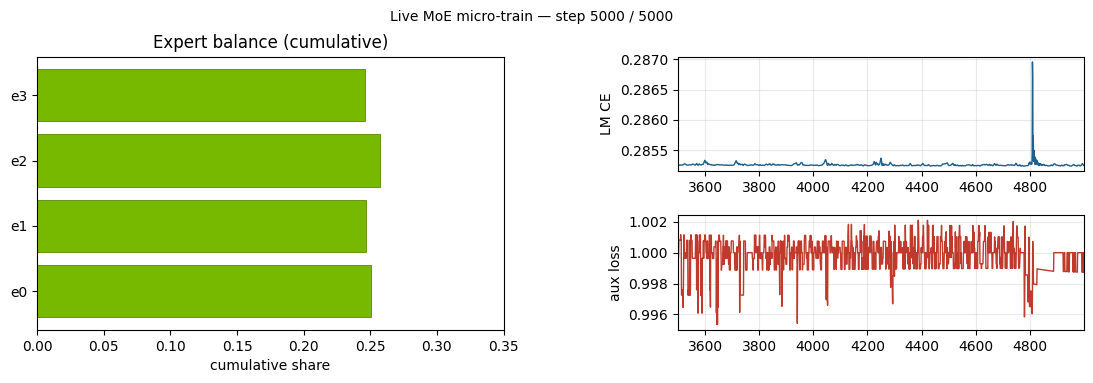

[   1/5000]  cumulative  e0:25.8%  e1:23.8%  e2:27.8%  e3:22.6%   H=1.383  max=27.8%
         recent≤ 1    e0:25.8%  e1:23.8%  e2:27.8%  e3:22.6%   H=1.383  max=27.8%


/tmp/ipykernel_9446/1480141237.py:219: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax_lm.set_xlim(float(xs[0]), float(xs[-1]))
/tmp/ipykernel_9446/1480141237.py:220: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax_aux.set_xlim(float(xs[0]), float(xs[-1]))


[ 625/5000]  cumulative  e0:24.1%  e1:23.6%  e2:26.6%  e3:25.6%   H=1.385  max=26.6%
         recent≤30    e0:24.6%  e1:24.7%  e2:25.0%  e3:25.7%   H=1.386  max=25.7%
[1250/5000]  cumulative  e0:24.4%  e1:24.1%  e2:26.0%  e3:25.5%   H=1.386  max=26.0%
         recent≤30    e0:24.9%  e1:24.5%  e2:25.1%  e3:25.4%   H=1.386  max=25.4%
[1875/5000]  cumulative  e0:24.8%  e1:24.4%  e2:26.1%  e3:24.7%   H=1.386  max=26.1%
         recent≤30    e0:26.7%  e1:26.5%  e2:26.2%  e3:20.6%   H=1.381  max=26.7%
[2500/5000]  cumulative  e0:25.0%  e1:24.7%  e2:26.1%  e3:24.2%   H=1.386  max=26.1%
         recent≤30    e0:24.7%  e1:26.2%  e2:25.4%  e3:23.7%   H=1.386  max=26.2%
[3125/5000]  cumulative  e0:25.1%  e1:24.6%  e2:26.1%  e3:24.3%   H=1.386  max=26.1%
         recent≤30    e0:24.6%  e1:24.6%  e2:25.4%  e3:25.4%   H=1.386  max=25.4%
[3750/5000]  cumulative  e0:25.0%  e1:24.6%  e2:25.9%  e3:24.4%   H=1.386  max=25.9%
         recent≤30    e0:24.9%  e1:24.7%  e2:25.4%  e3:24.9%   H=1.386  max=25.4

In [1]:
# --- Same helper as §6.6 (defined here so this section runs standalone) ---
def moe_preflight(cfg):
    """Check critical MoE settings. Pass a flat dict of model flags."""
    get = lambda c, k: c.get(k) if isinstance(c, dict) else getattr(c, k, None)
    checks = []
    checks.append(("moe_grouped_gemm", get(cfg, "moe_grouped_gemm") is True))
    checks.append(("moe_permute_fusion", get(cfg, "moe_permute_fusion") is True))
    checks.append(
        (
            "load_balancing set",
            get(cfg, "moe_router_load_balancing_type") in ("aux_loss", "sinkhorn", "aux_loss_free"),
        )
    )
    checks.append(("moe_aux_loss_coeff", get(cfg, "moe_aux_loss_coeff") is not None))
    checks.append(("moe_router_topk", get(cfg, "moe_router_topk") in (1, 2)))
    all_ok = all(c[1] for c in checks)
    for name, ok in checks:
        print(f"  {'✓' if ok else '✗'} {name}")
    return all_ok


# Flat dict aligned with `moe_config` (re-run the moe_config cell first for a strict match)
try:
    _mc = moe_config
    training_flags = {}
    for _settings in _mc.values():
        if isinstance(_settings, dict):
            training_flags.update(_settings)
except NameError:
    training_flags = {
        "num_experts": 4,
        "moe_router_topk": 2,
        "moe_router_load_balancing_type": "aux_loss",
        "moe_aux_loss_coeff": 1e-2,
        "moe_grouped_gemm": True,
        "moe_permute_fusion": True,
        "moe_token_dispatcher_type": "allgather",
    }

print("Pre-flight (Megatron-style flags you set in Bridge/Core — we only validate the dict):")
_ = moe_preflight(training_flags)

import math
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    _tqdm = None  # optional: pip install tqdm

# Micro model dims (fast on CPU or GPU)
B, S, H = 4, 32, 64
V = 256  # vocab
num_experts = int(training_flags["num_experts"])
top_k = int(training_flags["moe_router_topk"])
aux_coeff = float(training_flags["moe_aux_loss_coeff"])
train_steps = 5000
lr = 3e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)


def switch_aux_loss(router_logits: torch.Tensor, expert_idx: torch.Tensor, n_exp: int) -> torch.Tensor:
    """Encourage uniform routing (Switch-style auxiliary term)."""
    probs = F.softmax(router_logits, dim=-1)
    # fraction of routing decisions landing on each expert
    mask = F.one_hot(expert_idx, n_exp).float()
    density = mask.mean(dim=(0, 1))
    importance = probs.mean(0)
    return n_exp * (density * importance).sum()


def _expert_balance_stats(counts: torch.Tensor):
    """Entropy (nats), max share, normalized distribution from expert-slot counts."""
    tot = counts.sum().clamp_min(1.0)
    p = counts / tot
    ps = p.clamp_min(1e-12)
    H = -(ps * ps.log()).sum().item()
    mx = float(p.max().item())
    return H, mx, p


def _expert_share_row(p: torch.Tensor) -> str:
    """Single-line expert percentages for logging."""
    return "  ".join(f"e{i}:{100 * float(p[i]):4.1f}%" for i in range(p.shape[0]))


class TinyMoE(nn.Module):
    def __init__(self, hidden: int, n_exp: int, k: int):
        super().__init__()
        self.k = k
        self.router = nn.Linear(hidden, n_exp, bias=False)
        self.experts = nn.ModuleList(
            nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden))
            for _ in range(n_exp)
        )
        self.norm = nn.LayerNorm(hidden)

    def forward(self, x: torch.Tensor):
        # x: [B, S, H]
        b, s, h = x.shape
        flat = x.reshape(b * s, h)
        logits = self.router(flat)
        probs = F.softmax(logits, dim=-1)
        top_p, top_idx = torch.topk(probs, self.k, dim=-1)
        top_p = top_p / (top_p.sum(dim=-1, keepdim=True) + 1e-9)

        out = torch.zeros_like(flat)
        for ki in range(self.k):
            idx_k = top_idx[:, ki]
            w_k = top_p[:, ki : ki + 1]
            for e in range(len(self.experts)):
                m = idx_k == e
                if m.any():
                    out[m] = out[m] + w_k[m] * self.experts[e](flat[m])

        aux = switch_aux_loss(logits, top_idx, len(self.experts))
        return self.norm(out).reshape(b, s, h), aux, top_idx.detach()


class TinyLM(nn.Module):
    def __init__(self, vocab: int, hidden: int, n_exp: int, k: int):
        super().__init__()
        self.embed = nn.Embedding(vocab, hidden)
        self.moe = TinyMoE(hidden, n_exp, k)
        self.lm_head = nn.Linear(hidden, vocab, bias=False)

    def forward(self, input_ids: torch.Tensor):
        h = self.embed(input_ids)
        h, aux, top_idx = self.moe(h)
        return self.lm_head(h), aux, top_idx


model = TinyLM(V, H, num_experts, top_k).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=lr)

# Synthetic LM batch (repeatable)
data_ids = torch.randint(0, V, (B, S), device=device)

history = {"lm": [], "aux": []}
cum_expert = torch.zeros(num_experts, device=device)
recent_slots = deque(maxlen=min(30, train_steps))
report_every = max(5, train_steps // 8)

steps = range(train_steps)
pbar = _tqdm(steps, desc="MoE micro-train", unit="step", mininterval=0.2) if _tqdm else steps

# Live matplotlib in Jupyter: one `display_id` + `handle.update(fig)` so tqdm text is not cleared.
LIVE = {}


def _try_init_live_plots() -> None:
    try:
        from IPython import get_ipython

        if get_ipython() is None:
            return
        import matplotlib.pyplot as plt
        import numpy as np

        plt.ioff()
        fig = plt.figure(figsize=(11.5, 3.9))
        gs = fig.add_gridspec(
            2,
            2,
            width_ratios=[1.15, 1.0],
            height_ratios=[1, 1],
            wspace=0.4,
            hspace=0.38,
            left=0.07,
            right=0.98,
            top=0.86,
            bottom=0.16,
        )
        ax_bar = fig.add_subplot(gs[:, 0])
        ax_lm = fig.add_subplot(gs[0, 1])
        ax_aux = fig.add_subplot(gs[1, 1])
        LIVE["fig"] = fig
        LIVE["axes"] = (ax_bar, ax_lm, ax_aux)
        LIVE["np"] = np
        from IPython.display import display

        LIVE["handle"] = display(fig, display_id="moe-hands-on-live")
    except Exception:
        LIVE.clear()


def _refresh_live_plots(step: int) -> None:
    if not LIVE:
        return
    fig, axes, np = LIVE["fig"], LIVE["axes"], LIVE["np"]
    ax_bar, ax_lm, ax_aux = axes
    handle = LIVE.get("handle")
    tot = cum_expert.sum().clamp_min(1.0)
    sh = (cum_expert / tot).detach().cpu().numpy()
    ax_bar.clear()
    y = np.arange(num_experts)
    ax_bar.barh(y, sh, color="#76B900", edgecolor="#5A8700", linewidth=0.6)
    ax_bar.set_yticks(y, [f"e{i}" for i in range(num_experts)])
    ax_bar.set_xlim(0, max(0.35, float(sh.max()) * 1.12))
    ax_bar.set_xlabel("cumulative share")
    ax_bar.set_title("Expert balance (cumulative)")
    tail = min(1500, len(history["lm"]))
    if tail > 0:
        xs = np.arange(step - tail + 1, step + 1, dtype=np.float64)
        ax_lm.clear()
        ax_aux.clear()
        ax_lm.plot(xs, history["lm"][-tail:], color="#1f618d", lw=1.0)
        ax_lm.set_ylabel("LM CE")
        ax_lm.grid(True, alpha=0.28)
        ax_aux.plot(xs, history["aux"][-tail:], color="#c0392b", lw=1.0)
        ax_aux.set_ylabel("aux loss")
        ax_aux.grid(True, alpha=0.28)
        ax_lm.set_xlim(float(xs[0]), float(xs[-1]))
        ax_aux.set_xlim(float(xs[0]), float(xs[-1]))
    fig.suptitle(f"Live MoE micro-train — step {step + 1} / {train_steps}", fontsize=10)
    fig.canvas.draw_idle()
    if handle is not None:
        try:
            handle.update(fig)
        except Exception:
            pass


_try_init_live_plots()
if not LIVE:
    try:
        from IPython import get_ipython as _gi

        _ipy = _gi()
    except Exception:
        _ipy = None
    if _ipy is None:
        print("(Skipping live matplotlib: not in an IPython notebook session.)")
    else:
        print("(Skipping live matplotlib: install matplotlib or display init failed.)")


def _live_log(msg: str) -> None:
    if _tqdm is not None:
        pbar.write(msg)
    else:
        print(msg)


model.train()
for step in pbar:
    opt.zero_grad(set_to_none=True)
    logits, aux, top_idx = model(data_ids[:, :-1])
    loss_lm = F.cross_entropy(
        logits.reshape(-1, V), data_ids[:, 1:].reshape(-1)
    )
    loss = loss_lm + aux_coeff * aux
    loss.backward()
    opt.step()

    history["lm"].append(loss_lm.item())
    history["aux"].append(aux.item())

    with torch.no_grad():
        slot = F.one_hot(top_idx, num_experts).float().sum(dim=(0, 1))
        cum_expert += slot
        recent_slots.append(slot.detach())
        win = torch.stack(list(recent_slots)).sum(dim=0)
        H_run, mx_run, p_cum = _expert_balance_stats(cum_expert)
        H_win, mx_win, p_win = _expert_balance_stats(win)
        H_uniform = math.log(num_experts)

    log_now = (step == 0) or ((step + 1) % report_every == 0) or (step == train_steps - 1)
    if log_now:
        _live_log(
            f"[{step + 1:4d}/{train_steps}]  cumulative  {_expert_share_row(p_cum)}   "
            f"H={H_run:.3f}  max={100 * mx_run:.1f}%"
        )
        _live_log(
            f"{'':9}recent≤{len(recent_slots):2d}    {_expert_share_row(p_win)}   "
            f"H={H_win:.3f}  max={100 * mx_win:.1f}%"
        )
        _refresh_live_plots(step)

    if _tqdm is not None:
        pbar.set_postfix(
            lm=f"{loss_lm.item():.3f}",
            aux=f"{aux.item():.3f}",
            max_pct=f"{100 * mx_run:.1f}%",
            H=f"{H_run:.2f}/{H_uniform:.2f}",
            refresh=False,
        )

_refresh_live_plots(train_steps - 1)

print(f"\nDevice: {device} | steps={train_steps} | aux_coeff={aux_coeff}")
print("Last 5 LM losses:", [round(x, 4) for x in history["lm"][-5:]])
print("Last 5 aux losses:", [round(x, 4) for x in history["aux"][-5:]])

H_fin, mx_fin, p_fin = _expert_balance_stats(cum_expert)
share = p_fin.detach().cpu()
H_uniform = math.log(num_experts)
uniform_pct = 100.0 / num_experts

w = 52
line = "  " + "-" * w
print()
print(line)
print("  Post-flight: cumulative expert usage (all steps, top-k slots)")
print(line)
print(f"  {'expert':<10} {'share':>8}     delta vs {uniform_pct:.1f}% uniform")
print("  " + "-" * (w - 2))
for i in range(num_experts):
    pct = 100.0 * float(share[i])
    d = pct - uniform_pct
    print(f"  e{i:<9} {pct:6.1f}%     {d:+6.1f} pp")
print(line)
print(f"  max expert share     {100.0 * mx_fin:5.1f}%")
print(f"  routing entropy      {H_fin:5.3f} nats   (uniform ideal: {H_uniform:.3f})")
print(line)
if mx_fin > 0.45:
    print("  Tip: one expert >45% — try raising moe_aux_loss_coeff or router LR (§6.2).")
else:
    print("  Tip: balance looks healthy for this toy run.")

if LIVE.get("fig") is not None:
    import matplotlib.pyplot as plt

    plt.close(LIVE["fig"])
LIVE.clear()



## 6. Training checklist (short) 🏋️

Use before a long MoE **training** run. Extended tips and multi-GPU notes are in the **Appendix**.

- [ ] **Load balancing:** `aux_loss` + `moe_aux_loss_coeff` ~ `1e-2` (raise if one expert >40% of tokens)
- [ ] **Routing:** prefer **top-2** for quality; top-1 only if compute-bound and validated
- [ ] **Throughput:** `moe_grouped_gemm: True`, `moe_permute_fusion: True`
- [ ] **Batching:** start `micro_batch_size` 1–2; increase only with GPU headroom
- [ ] **Sanity run:** ~100 steps, 2 experts, top-1 — confirm loss moves before scaling up
- [ ] **Pre-flight:** same checks as the micro-train cell (grouped GEMM, aux coeff, topk)
- [ ] **Multi-GPU (EP>1):** scale EP toward `num_experts` first; see appendix for dispatcher / overlap


---

## Appendix: Multi-GPU & Megatron (optional) 🖥️

*Path 2 — distributed training and production layouts. **Skip** if you only followed Path 1 on one GPU.*

### Routing vs dispatch (recap)

| Step | Name | What happens |
|------|------|----------------|
| 1 | **Routing** | Router scores experts; pick top-k (**decision**) |
| 2 | **Dispatch** | Move activations to the GPU that **owns** those experts |
| 3 | **Expert compute** | GroupedGEMM / MLP on expert-wise batches |
| 4 | **Combine** | Weighted sum back into the token stream |

### Token dispatch mechanisms

After routing, tokens must reach the correct experts (on other GPUs when EP > 1):

- **Dropless** vs **capacity-based**: dropless processes all tokens (may imbalance); capacity-based may **drop** overflow tokens during **training** for balance.
- **allgather** dispatcher: gather tokens, route locally, scatter — good for small EP.
- **alltoall** dispatcher: each rank exchanges tokens with peers — better at larger EP.
- **FlexEP / DeepEP / HybridEP**: advanced cluster backends.

- Flag: `--moe-token-dispatcher-type`

### Dispatch under the hood

#### allgather


In [ ]:
# EP = 2
#
# Rank 0 local: X0 ∈ R[B × H]
# Rank 1 local: X1 ∈ R[B × H]
#
# Allgather over EP group:
#   each rank gets X_all ∈ R[2B × H] = concat(X0, X1)
#
# Routing + expert grouping (done independently on each rank):
#   X_all ──router/top-k──> token→expert assignments
#         ──permute──────> expert-wise batches
#         ──GroupedGEMM──> expert outputs
#         ──unpermute────> Y_all ∈ R[2B × H]
#
# Slice back local outputs:
#   Rank 0 keeps first B tokens → Y0 ∈ R[B × H]
#   Rank 1 keeps last  B tokens → Y1 ∈ R[B × H]

### alltoall

In [ ]:
# EP group: 4 ranks, each has X_i ∈ R[B × H]
#
# Step 1: route tokens → decide expert rank for each token
#   token i on rank r gets target_rank ∈ {0, 1, 2, 3}
#
# Step 2: bucket tokens by target_rank:
#   send[r→0], send[r→1], send[r→2], send[r→3]
#
# Alltoall over EP group:
#   Rank 0 receives [send[0→0], send[1→0], send[2→0], send[3→0]] = X_0_recv
#   Rank 1 receives X_1_recv
#   Rank 2 receives X_2_recv
#   Rank 3 receives X_3_recv
#
# Each rank now has only tokens whose experts live on that rank:
#   X_k_recv ──expert MLPs──> Y_k_recv
#
# (Optional) second alltoall to return outputs to original owners.

### Emulate multi-GPU EP on one device (debug)

Megatron-Core supports `fake_init_process_group` to emulate parallel groups (TP, PP, EP) on **one** GPU — useful before scaling out.

```python
cfg.train.fake_init_process_group = True
cfg.parallelism.expert_model_parallel_size = 2  # Emulate EP=2 on one GPU
```


### Tensor, pipeline, and expert parallel

Large MoE runs are usually laid out along **three independent axes**. You can combine them, but each axis trades a different bottleneck.

![TP vs PP vs EP axes](moe_assets/moe_parallel_axes.png)

#### What each axis does

- **Tensor parallel (TP)** — splits **one layer's matrices** across GPUs (column/row parallel matmuls). 
    - **Good for** very wide hidden sizes that do not fit on one device. 
    - **Cost:** frequent **all-reduce** on activations every layer; less helpful as the *first* knob for MoE capacity because it does not reduce the *count* of expert parameters.

- **Pipeline parallel (PP)** — splits **depth** so each rank owns a contiguous **stage** of layers. 
    - **Good for** models that are too deep to fit even when experts are sharded. 
    - **Cost:** pipeline **bubble** and careful microbatch scheduling to keep GPUs busy.

- **Expert parallel (EP)** — shards **experts** across ranks; each rank runs only the experts it owns, and token routing uses **allgather / alltoall** (and optional overlap) to move token activations to the right rank. 
    - **Good for** MoE first: total expert FFN capacity scales with `num_experts`, and EP is how you spread that memory without splitting every expert matrix at once.

#### Rule of thumb for MoE

Push **EP** up toward the number of experts so expert weights spread across the machine; add **TP** when a *single* expert (or attention stack beside the MoE) is still too large for one GPU; add **PP** when the full layer stack still does not fit even after EP/TP.



### Full Megatron-Bridge pretrain template (reference only)

*Requires Megatron-Bridge. Reference only — do not run unless installed.*

```python

# Conceptual configuration structure (requires Megatron-Bridge installation)
config_template = '''
from megatron.bridge.recipes.llama import llama32_1b_pretrain_config
from megatron.bridge.training.gpt_step import forward_step
from megatron.bridge.training.pretrain import pretrain

# Start from Llama 1B base config
cfg = llama32_1b_pretrain_config(seq_length=1024)

# Training settings
cfg.train.train_iters = 10
cfg.train.global_batch_size = 8
cfg.train.micro_batch_size = 1

# Parallelism: single GPU
cfg.parallelism.tensor_model_parallel_size = 1
cfg.parallelism.pipeline_model_parallel_size = 1
cfg.parallelism.expert_model_parallel_size = 1

# MoE configuration
cfg.model.num_experts = 4
cfg.model.moe_router_topk = 2
cfg.model.moe_router_load_balancing_type = "aux_loss"
cfg.model.moe_aux_loss_coeff = 1e-2

# MoE performance knobs
cfg.model.moe_grouped_gemm = True
cfg.model.moe_permute_fusion = True
cfg.model.moe_token_dispatcher_type = "allgather"

# Launch training
if __name__ == "__main__":
    pretrain(cfg, forward_step)
'''

print("Complete Megatron-Bridge Configuration:\n")
print(config_template)
print("\nLaunch with: torchrun --nproc-per-node=1 moe_train.py")
```


### Production MoE configurations

#### Example: Mixtral-style 8×7B MoE Training

Mixtral 8×7B is a popular MoE architecture: 8 experts, top-2 routing, with each expert roughly 7B dense params. Below: a parallelism map for a 64-GPU layout, then a **Megatron-Bridge** recipe (Megatron-Core remains the runtime underneath).


Reference: Mixtral 8×7B parallelism walkthrough.

```python

# Understanding the Mixtral 8x7B parallelism strategy
parallelism_breakdown = {
    "Tensor Parallel (TP)": {
        "value": 2,
        "description": "Each expert's weight matrices split across 2 GPUs",
        "communication": "allreduce for activations"
    },
    "Pipeline Parallel (PP)": {
        "value": 4,
        "description": "Model layers divided into 4 pipeline stages",
        "communication": "p2p send/recv between stages"
    },
    "Expert Parallel (EP)": {
        "value": 8,
        "description": "8 experts distributed across GPU groups",
        "communication": "alltoall for token routing"
    }
}

print("Mixtral 8×7B Parallelism Strategy:\n")
total_gpus = 1
for strategy, details in parallelism_breakdown.items():
    total_gpus *= details['value']
    print(f"{strategy}: {details['value']}")
    print(f"  → {details['description']}")
    print(f"  → Communication: {details['communication']}\n")

print(f"Total GPUs Required: TP × PP × EP = 2 × 4 × 8 = {total_gpus}")
print("\nKey Optimizations:")
print("  • alltoall dispatcher: More efficient than allgather at EP ≥ 4")
print("  • GroupedGEMM + permute fusion: Critical for performance")
print("  • Communication overlap: Hides alltoall latency behind compute")
```


### Megatron-Bridge configuration

Production-scale MoE pretrain using **Megatron-Bridge** (the same knobs as in §2, as a typed Python recipe rather than a shell flag dump).

Reference: Mixtral-style 8×7B settings on **64 GPUs** (TP=2, PP=4, EP=8). Run with your cluster entrypoint (for example `torchrun` per Megatron-Bridge / NeMo docs).

```python

from megatron.bridge.recipes.llama import llama32_1b_pretrain_config
from megatron.bridge.training.gpt_step import forward_step
from megatron.bridge.training.pretrain import pretrain

cfg = llama32_1b_pretrain_config(seq_length=4096)

# Model architecture
cfg.model.num_layers = 32
cfg.model.hidden_size = 4096
cfg.model.num_attention_heads = 32
cfg.model.max_position_embeddings = 32768

# MoE configuration
cfg.model.num_experts = 8
cfg.model.moe_router_topk = 2
cfg.model.moe_router_load_balancing_type = "aux_loss"
cfg.model.moe_aux_loss_coeff = 1e-2

# MoE performance
cfg.model.moe_grouped_gemm = True
cfg.model.moe_permute_fusion = True
cfg.model.moe_token_dispatcher_type = "alltoall"

# Parallelism (64 GPUs: TP=2, PP=4, EP=8)
cfg.parallelism.tensor_model_parallel_size = 2
cfg.parallelism.pipeline_model_parallel_size = 4
cfg.parallelism.expert_model_parallel_size = 8
cfg.parallelism.overlap_moe_expert_parallel_comm = True

# Training
cfg.train.train_iters = 100000
cfg.train.global_batch_size = 512
cfg.train.micro_batch_size = 1
cfg.train.lr = 1e-4
cfg.train.bf16 = True

if __name__ == "__main__":
    pretrain(cfg, forward_step)
```


### Performance tuning guide

#### Key optimizations

Based on our exploration, here are the critical settings for MoE performance:



```python
# Performance tuning matrix
tuning_guide = {
    "Max Throughput": {
        "Flags": [
            "--moe-grouped-gemm",
            "--moe-permute-fusion",
            "--overlap-moe-expert-parallel-comm",
            "--moe-token-dispatcher-type alltoall"
        ],
        "Notes": "GroupedGEMM is critical. alltoall scales better than allgather at EP ≥ 4."
    },
    "Long Context (32k+ tokens)": {
        "Flags": [
            "--moe-router-load-balancing-type aux_loss",
            "--moe-router-topk 2",
            "--sequence-parallel"
        ],
        "Notes": "aux_loss is lighter than Sinkhorn. Top-2 routing improves quality."
    },
    "Minimize GPU Count": {
        "Flags": [
            "--expert-model-parallel-size <num_experts>",
            "--tensor-model-parallel-size 1",
            "--moe-token-dispatcher-type dropless"
        ],
        "Notes": "High EP, low TP. Dropless ensures no quality loss from token dropping."
    },
    "Fast Iteration / Debug": {
        "Flags": [
            "--fake-init-process-group",
            "--num-experts 2",
            "--moe-router-topk 1"
        ],
        "Notes": "Single-GPU emulation. Minimal experts/routing for fast iteration."
    }
}

print("MoE Performance Tuning Guide\n")
print("="*70)

for goal, details in tuning_guide.items():
    print(f"\n{goal}:")
    print("  Key Flags:")
    for flag in details["Flags"]:
        print(f"    • {flag}")
    print(f"  Notes: {details['Notes']}")
```


### Common Issues and Solutions

```python

common_issues = [
    {
        "Symptom": "Training much slower than expected dense model",
        "Likely Cause": "GroupedGEMM or permute fusion not enabled",
        "Fix": "Add --moe-grouped-gemm and --moe-permute-fusion"
    },
    {
        "Symptom": "High expert load imbalance (90% tokens → 2 experts)",
        "Likely Cause": "No load balancing or aux_loss too low",
        "Fix": "Set --moe-router-load-balancing-type aux_loss, increase --moe-aux-loss-coeff to 5e-2"
    },
    {
        "Symptom": "OOM (out of memory) on expected GPU count",
        "Likely Cause": "EP parallelism not reducing memory per GPU",
        "Fix": "Verify --expert-model-parallel-size is set; check TP × PP × EP matches GPU count"
    },
    {
        "Symptom": "Low GPU utilization",
        "Likely Cause": "Token dispatcher overhead or EP communication not overlapped",
        "Fix": "Switch to alltoall dispatcher and enable --overlap-moe-expert-parallel-comm"
    },
    {
        "Symptom": "Poor quality vs dense baseline",
        "Likely Cause": "Router not learning well or too few active experts",
        "Fix": "Increase --moe-router-topk from 1 to 2, tune aux_loss_coeff, check router learning rate"
    }
]

print("\nCommon Issues and Solutions")
print("="*70)

for i, issue in enumerate(common_issues, 1):
    print(f"\n{i}. {issue['Symptom']}")
    print(f"   Cause: {issue['Likely Cause']}")
    print(f"   Fix:   {issue['Fix']}")
```


### Extended training tips (full detail)

*Optional depth beyond the §6 checklist in the main path.*

Code-ready tips for MoE training.

#### 6.1 Learning rate and warmup

Give the router a slightly longer warmup than dense models; cosine or linear decay. A higher router LR can help specialization early.


Reference: LR / warmup fields to set in your trainer config.

```python

lr_warmup_tips = {
    "warmup_steps_ratio": 0.02,
    "lr_schedule": "cosine",
    "lr": 1e-4,
    "min_lr": 1e-5,
    "router_lr_scale": 1.0,
}
print("LR / warmup settings (use in your config):")
for k, v in lr_warmup_tips.items():
    print(f"  {k}: {v}")
```


#### 6.2 Load balancing
Use `aux_loss` with `moe_aux_loss_coeff` (e.g. 1e-2) so experts are used more evenly. Log per-expert token counts every N steps—if one or two experts take >40% of tokens, increase the coeff or check the router learning rate.


#### Simulated expert token share (illustrative)

One-off Dirichlet sample as a stand-in for logged per-expert counts. Reproducible with `np.random.seed(42)`.

```python

moe_load_balance = {
    "moe_router_load_balancing_type": "aux_loss",
    "moe_aux_loss_coeff": 1e-2,
}

import numpy as np
num_experts = 8
np.random.seed(42)
expert_counts = np.random.dirichlet(np.ones(num_experts) * 2).round(3)
print("Load balancing config:", moe_load_balance)
print("\nSimulated expert token share (aim for ~uniform; watch for collapse):")
for i, c in enumerate(expert_counts):
    bar = "█" * int(c * 40) + "░" * (40 - int(c * 40))
    print(f"  Expert {i}: {bar} {c:.2%}")
if expert_counts.max() > 0.4:
    print("  → Consider increasing moe_aux_loss_coeff or checking router LR.")
```

**Example output (seed 42)**

```text
Load balancing config: {'moe_router_load_balancing_type': 'aux_loss', 'moe_aux_loss_coeff': 0.01}

Simulated expert token share (aim for ~uniform; watch for collapse):
  Expert 0: █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 13.50%
  Expert 1: ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 8.40%
  Expert 2: ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 7.80%
  Expert 3: ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 7.80%
  Expert 4: ██████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 26.20%
  Expert 5: ██████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 16.10%
  Expert 6: ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 6.40%
  Expert 7: █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 13.90%
```


#### 6.3 Memory and throughput
Always turn on GroupedGEMM and permute fusion; leaving them off is a common cause of slow training and OOM. Start with a small micro_batch_size (1 or 2) and only increase it if the GPU has headroom, since large micro-batches can worsen expert imbalance.


Reference: must-have MoE performance flags and batching tips.

```python

must_have_moe_flags = {
    "moe_grouped_gemm": True,
    "moe_permute_fusion": True,
}
micro_batch_tip = {"micro_batch_size": 1}
long_context_tip = {"sequence_parallel": True, "micro_batch_size": 1}

print("Must-have MoE flags:", must_have_moe_flags)
print("Micro-batch (start conservative):", micro_batch_tip)
print("Long context:", long_context_tip)
```


#### 6.4 Parallelism and dispatch
Scale expert parallelism (EP) first, up to the number of experts, before increasing tensor or pipeline parallel. Use the allgather dispatcher for small EP (2–4) and alltoall for larger EP, and enable communication overlap. To debug on one GPU, use fake init with EP=2 to emulate routing and communication.


Reference: parallelism and single-GPU fake-EP debug fields.

```python

parallelism_tips = {
    "expert_model_parallel_size": 8,
    "tensor_model_parallel_size": 1,
    "pipeline_model_parallel_size": 1,
    "moe_token_dispatcher_type": "alltoall",
    "overlap_moe_expert_parallel_comm": True,
}
single_gpu_debug = {
    "fake_init_process_group": True,
    "expert_model_parallel_size": 2,
}
print("Multi-GPU parallelism (EP first):", parallelism_tips)
print("\nSingle-GPU debug (emulate EP on one device):", single_gpu_debug)
```


#### 6.5 Quality and sanity checks
Top-2 routing usually gives better quality than top-1; reserve top-1 for when you are compute-bound and have already checked quality. Before a long run, do a short sanity run (e.g. 100 steps, 2 experts, top-1) to confirm the data path and loss scaling.


Reference: quality defaults vs short sanity-run sizes.

```python

quality_tips = {
    "moe_router_topk": 2,
    "num_experts": 8,
}
sanity_run_config = {
    "num_experts": 2,
    "moe_router_topk": 1,
    "train_iters": 100,
}
print("Production (top-2 for quality):", quality_tips)
print("Sanity run (quick check):", sanity_run_config)
```


#### 6.6 Pre-flight checklist
Before starting a long MoE run, verify that GroupedGEMM, permute fusion, load balancing type, and aux loss coeff are set correctly. The reference snippet in the previous cell defines `moe_preflight`, which checks a config dict (or config object) and prints pass/fail for each critical setting.


Reference: `moe_preflight` helper (also embedded in the hands-on training cell for standalone runs).

```python
def moe_preflight(cfg):
    """Check that critical MoE settings are set. Pass a dict or object with .get or getattr."""
    get = lambda c, k: c.get(k) if isinstance(c, dict) else getattr(c, k, None)
    checks = []
    checks.append(("moe_grouped_gemm", get(cfg, "moe_grouped_gemm") is True))
    checks.append(("moe_permute_fusion", get(cfg, "moe_permute_fusion") is True))
    checks.append(("load_balancing set", get(cfg, "moe_router_load_balancing_type") in ("aux_loss", "sinkhorn", "aux_loss_free")))
    checks.append(("moe_aux_loss_coeff", get(cfg, "moe_aux_loss_coeff") is not None))
    checks.append(("moe_router_topk", get(cfg, "moe_router_topk") in (1, 2)))
    all_ok = all(c[1] for c in checks)
    for name, ok in checks:
        print(f"  {'✓' if ok else '✗'} {name}")
    return all_ok

example_cfg = {
    "moe_grouped_gemm": True,
    "moe_permute_fusion": True,
    "moe_router_load_balancing_type": "aux_loss",
    "moe_aux_loss_coeff": 1e-2,
    "moe_router_topk": 2,
}
print("MoE pre-flight checklist:")
moe_preflight(example_cfg)
```


#### 6.7 Lower precision (FP8 / BF16)
BF16 or FP16 is the usual baseline for MoE training. FP8 reduces memory and can speed up on supported hardware (e.g. H100+); it requires specific Megatron-Core/Bridge support and is typically enabled via config or CLI flags. Use it when you are memory- or throughput-bound and have validated stability.


Reference: typical precision switches (exact FP8 keys depend on your Bridge/Core version).

```python

# Typical precision settings (Megatron-Bridge / Core)
# BF16 is the default for most MoE training.
precision_baseline = {"bf16": True}
# FP8: enable when on H100 (or compatible) and you need more throughput or lower memory.
# Exact keys depend on your Megatron-Bridge version (e.g. fp8_linear, fp8_recipe).
precision_fp8 = {"fp8": True, "bf16": False}
print("Baseline (BF16):", precision_baseline)
print("FP8 (H100+):", precision_fp8)
```


## Summary

**Path 1 (essentials):** §1 when to use MoE → §2 concepts → §3 single-GPU micro-train → §6 checklist.

**Path 2 (appendix):** dispatch, EP/TP/PP, production configs, performance tuning, extended training tips.

### Key takeaways

- MoE scales **capacity** (total params) more than **per-token compute** (top-k experts).
- Routing is **per token**; `aux_loss` is **training only**.
- On one GPU, experts stay **in memory**; sparsity saves **compute**, not weight RAM.
- Multi-GPU needs **dispatch** and the right **dispatcher** (allgather vs alltoall).

### Next steps

- Run the micro-train cell; inspect per-expert token counts.
- When scaling out, use the appendix and adapt production configs to your cluster.


## References

### Megatron Documentation

- [Megatron-Core MoE API Guide](https://docs.nvidia.com/megatron-core/developer-guide/latest/api-guide/moe.html)
- [Megatron-Core MoE README](https://github.com/NVIDIA/Megatron-LM/blob/main/megatron/core/transformer/moe/README.md)
- [Megatron-Bridge Documentation](https://docs.nvidia.com/nemo/megatron-bridge/latest/)

### Additional Resources

- [21medien MoE Overview](https://21medien.de/en/library/mixture-of-experts)
- [Mixtral of Experts Paper](https://arxiv.org/abs/2401.04088)
- [Switch Transformers (original sparse MoE work)](https://arxiv.org/abs/2101.03961)